# Phase 6, Milestone 4: full law of the variance clock by Feynman–Kac

This notebook is the reproducible computational record for
`PHASE_6_MILESTONE_4_FK_RESOLVENT.md`. It verifies:

1. the PDE characteristic function \(\phi(\xi)=u(T,x_0)\) against
   Monte Carlo (complex values, several \(\xi\));
2. the Fourier-series density of \(A_T=\int_0^T\rho_s\,ds\):
   normalization, nonnegativity diagnostic, and moment agreement with
   the Gauss-quadrature moments of Milestone 3;
3. the **FK price** of the spread one-touch against the Gamma
   moment-matched price and the exact Monte Carlo benchmark, for
   three driver volatilities;
4. convergence in the Fourier mode count \(K\) and the PDE grid.

The pricing path itself is fully deterministic — Monte Carlo appears
only as an independent benchmark. Seed `20260727`.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase6_fk.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase6_fk.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_fk as pf
import phase6_joint as pj

SEED = 20260727
rng = np.random.default_rng(SEED)

FIGURES = ROOT / "phase6_figures"
FIGURES.mkdir(exist_ok=True)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}


## 1. Parameters (Milestone 3 spread one-touch)

In [2]:
DRIVER = dict(x0=0.0, drift=0.3, volatility=0.8, scale=1.0)
SIGMA1, SIGMA2 = 1.5, 2.5
MATURITY = 1.0
DISTANCE = 2.0
RATE = 0.05
BETA = SIGMA1**2 + SIGMA2**2
ALPHA = -2.0 * SIGMA1 * SIGMA2

def q_spread(rho):
    return pj.q_variance(rho, alpha1=1.0, alpha2=-1.0, sigma1=SIGMA1, sigma2=SIGMA2)

def simulate_clock(n_paths, horizon, step, seed, driver):
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(horizon / step))
    state = np.full(n_paths, driver["x0"])
    rho_prev = state / np.sqrt(state**2 + driver["scale"]**2)
    a_acc = np.zeros(n_paths)
    v_acc = np.zeros(n_paths)
    sd = driver["volatility"] * np.sqrt(step)
    for _ in range(n_steps):
        state = state + driver["drift"] * step + sd * local_rng.standard_normal(n_paths)
        rho = state / np.sqrt(state**2 + driver["scale"]**2)
        a_acc += 0.5 * (rho_prev + rho) * step
        v_acc += 0.5 * (q_spread(rho_prev) + q_spread(rho)) * step
        rho_prev = rho
    return a_acc, v_acc

## 2. PDE characteristic function vs. Monte Carlo

In [3]:
a_mc, _ = simulate_clock(300_000, MATURITY, 1e-3, SEED, DRIVER)
print(f"{'xi':>8} {'PDE phi':>24} {'MC phi':>24} {'|diff|':>10} {'MC SE':>9}")
for xi in (1.0, 3.0, 6.0, 10.0):
    pde = pf.fk_characteristic(xi, maturity=MATURITY, **DRIVER, n_grid=800)
    draws = np.exp(1j * xi * a_mc)
    mc = draws.mean()
    se = draws.std(ddof=1) / np.sqrt(draws.size)
    print(f"{xi:8.1f} {pde.real:+10.6f}{pde.imag:+10.6f}j {mc.real:+10.6f}{mc.imag:+10.6f}j {abs(pde-mc):10.2e} {se:9.2e}")

      xi                  PDE phi                   MC phi     |diff|     MC SE
     1.0  +0.939716 +0.102106j  +0.939816 +0.102432j   3.41e-04  5.95e-04
     3.0  +0.541173 +0.212974j  +0.541893 +0.213866j   1.15e-03  1.48e-03


     6.0  -0.058726 +0.081487j  -0.057383 +0.082354j   1.60e-03  1.82e-03
    10.0  -0.019476 -0.045248j  -0.018970 -0.045506j   5.68e-04  1.82e-03


## 3. The density of \(A_T\): figure and diagnostics

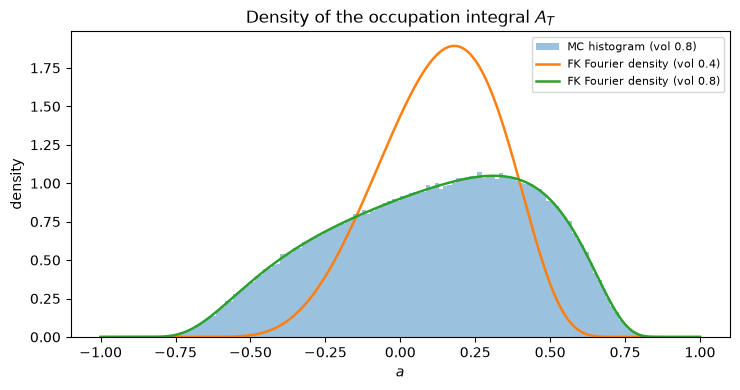

  vol       mass      min p    m1 (FK)  m1 (quad)   var (FK) var (quad)
  0.4  1.0000000  -8.95e-14   0.130832   0.130836   0.039680   0.039681
  0.8  1.0000000  -2.84e-10   0.106620   0.106629   0.111763   0.111738


In [4]:
densities = {}
for vol in (0.4, 0.8):
    driver = {**DRIVER, "volatility": vol}
    densities[vol] = pf.clock_density_grid(
        maturity=MATURITY, **driver, n_modes=64, n_points=1201, n_grid=800
    )

fig, ax = plt.subplots(figsize=(7.5, 4))
hist_a, _ = simulate_clock(300_000, MATURITY, 1e-3, SEED, DRIVER)
ax.hist(hist_a, bins=140, range=(-MATURITY, MATURITY), density=True,
        alpha=0.45, label="MC histogram (vol 0.8)")
for vol, (a, p) in densities.items():
    ax.plot(a, p, lw=1.8, label=rf"FK Fourier density (vol {vol})")
ax.set_xlabel(r"$a$"); ax.set_ylabel("density")
ax.set_title(r"Density of the occupation integral $A_T$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_fk_clock_density.png", dpi=150)
plt.show()

print(f"{'vol':>5} {'mass':>10} {'min p':>10} {'m1 (FK)':>10} {'m1 (quad)':>10} {'var (FK)':>10} {'var (quad)':>10}")
for vol, (a, p) in densities.items():
    mass = np.trapezoid(p, a)
    m1 = np.trapezoid(a * p, a)
    m2 = np.trapezoid(a**2 * p, a)
    mean_q, var_q = pj.occupation_moments(MATURITY, **{**DRIVER, "volatility": vol})
    print(f"{vol:5.1f} {mass:10.7f} {p.min():10.2e} {m1:10.6f} {mean_q:10.6f} {m2-m1**2:10.6f} {var_q:10.6f}")

## 4. FK price vs. Gamma price vs. Monte Carlo benchmark

In [5]:
print(f"{'vol':>6} {'FK':>10} {'gamma':>10} {'MC bench':>10} {'2 SE':>10} {'FK-gamma':>10} {'FK-MC z':>9}")
for vol in (0.4, 0.8, 1.2):
    driver = {**DRIVER, "volatility": vol}
    a, p = pf.clock_density_grid(
        maturity=MATURITY, **driver, n_modes=64, n_points=1201, n_grid=800
    )
    price_fk = pf.fk_touch_price(
        DISTANCE, maturity=MATURITY, rate=RATE, beta=BETA, alpha=ALPHA,
        a_grid=a, p_grid=p,
    )
    mean_v, var_v = pj.clock_moments(
        MATURITY, alpha1=1.0, alpha2=-1.0, sigma1=SIGMA1, sigma2=SIGMA2, **driver
    )
    price_gamma = pj.gamma_touch_price(
        DISTANCE, maturity=MATURITY, rate=RATE, mean_clock=mean_v, var_clock=var_v
    )
    n_bench = 100_000
    _, v_clock = simulate_clock(n_bench, MATURITY, 1e-3, SEED + 1, driver)
    probs = np.array([pj.driftless_touch_probability(DISTANCE, v) for v in v_clock])
    bench = np.exp(-RATE * MATURITY) * probs.mean()
    se = np.exp(-RATE * MATURITY) * probs.std(ddof=1) / np.sqrt(n_bench)
    z = (price_fk - bench) / se
    print(f"{vol:6.1f} {price_fk:10.6f} {price_gamma:10.6f} {bench:10.6f} {2*se:10.2e} {price_fk-price_gamma:+10.2e} {z:9.2f}")

   vol         FK      gamma   MC bench       2 SE   FK-gamma   FK-MC z


   0.4   0.437829   0.437876   0.437701   2.71e-04  -4.70e-05      0.94


   0.8   0.433501   0.434215   0.433305   4.65e-04  -7.14e-04      0.84


   1.2   0.428743   0.430854   0.428506   5.99e-04  -2.11e-03      0.79


## 5. Convergence: Fourier modes and PDE grid

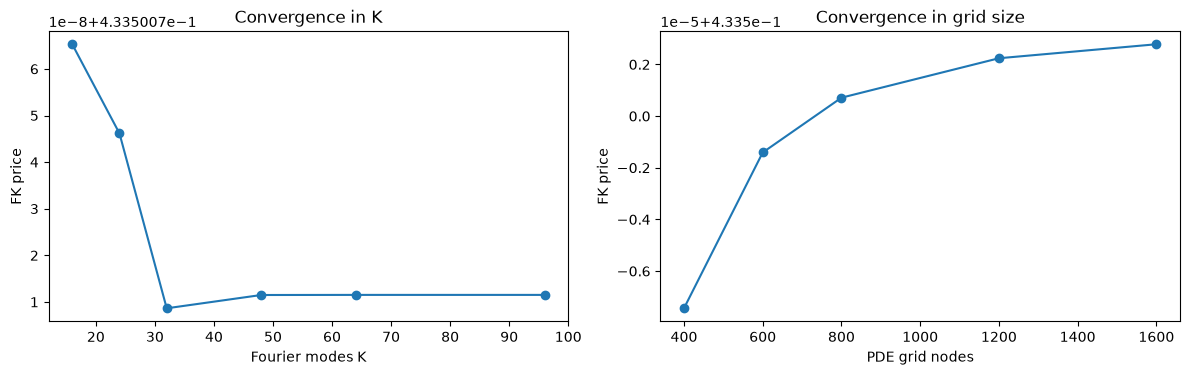

prices by K: ['0.433501', '0.433501', '0.433501', '0.433501', '0.433501', '0.433501']
prices by N: ['0.433493', '0.433499', '0.433501', '0.433502', '0.433503']


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mode_counts = (16, 24, 32, 48, 64, 96)
prices_by_k = []
for k in mode_counts:
    a, p = pf.clock_density_grid(
        maturity=MATURITY, **DRIVER, n_modes=k, n_points=1201, n_grid=800
    )
    prices_by_k.append(pf.fk_touch_price(
        DISTANCE, maturity=MATURITY, rate=RATE, beta=BETA, alpha=ALPHA,
        a_grid=a, p_grid=p,
    ))
axes[0].plot(mode_counts, prices_by_k, "o-")
axes[0].set_xlabel("Fourier modes K"); axes[0].set_ylabel("FK price")
axes[0].set_title("Convergence in K")

grids = (400, 600, 800, 1200, 1600)
prices_by_n = []
for n in grids:
    a, p = pf.clock_density_grid(
        maturity=MATURITY, **DRIVER, n_modes=64, n_points=1201, n_grid=n
    )
    prices_by_n.append(pf.fk_touch_price(
        DISTANCE, maturity=MATURITY, rate=RATE, beta=BETA, alpha=ALPHA,
        a_grid=a, p_grid=p,
    ))
axes[1].plot(grids, prices_by_n, "o-")
axes[1].set_xlabel("PDE grid nodes"); axes[1].set_ylabel("FK price")
axes[1].set_title("Convergence in grid size")
fig.tight_layout()
fig.savefig(FIGURES / "phase6_fk_convergence.png", dpi=150)
plt.show()
print("prices by K:", [f"{v:.6f}" for v in prices_by_k])
print("prices by N:", [f"{v:.6f}" for v in prices_by_n])

## 6. Runtime and reproducibility record

In [7]:
print(f"total runtime: {time.time() - started:.1f} s")
print(json.dumps(environment, indent=2))

total runtime: 121.4 s
{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}
